# Location-Based OOD Split Construction and Validation

## Purpose

This notebook constructs and validates the location-based out-of-distribution evaluation framework used throughout the thesis.

The objective is to reorganize the original xView2 dataset into training, validation, and final evaluation partitions that are disjoint at the disaster-location level while maintaining approximately comparable split sizes and class distributions.

## Motivation

Standard benchmark evaluation may underestimate the challenges encountered during deployment because disaster environments can be represented across multiple partitions. In operational settings, models are frequently applied to disaster locations that were not observed during training.

To better approximate these conditions, this thesis introduces a strict location-disjoint evaluation protocol.

The analyses performed in this notebook verify that the resulting partitions satisfy the intended OOD requirements.

## Main Tasks

* Construct location-disjoint OOD partitions
* Analyze split composition
* Analyze disaster allocation
* Analyze class distributions
* Verify disaster separation
* Verify image separation
* Validate the final OOD protocol

## Inputs

```text
processed/buildings_all_with_crops.csv
```

## Outputs

The notebook generates:

```text
OOD_train
OOD_test
OOD_hold
```

together with:

* OOD split composition tables
* Disaster allocation tables
* Class distribution summaries
* Overlap diagnostics
* Tables used in the methodology chapter

These outputs form the foundation of the controlled OOD evaluation framework used in the remainder of the thesis.


## OOD Split folders and inspect locations

In [12]:
from pathlib import Path
import shutil
import random
from collections import defaultdict

base = Path.home() / "Desktop"

source_splits = ["train", "test", "hold"]

ood_dirs = {
    "OOD_train": base / "OOD_train",
    "OOD_test": base / "OOD_test",
    "OOD_hold": base / "OOD_hold",
}

# Clean old OOD folders completely
for folder in ood_dirs.values():
    if folder.exists():
        shutil.rmtree(folder)

for folder in ood_dirs.values():
    (folder / "images").mkdir(parents=True, exist_ok=True)
    (folder / "labels").mkdir(parents=True, exist_ok=True)

def get_image_id_from_json(json_path):
    return json_path.stem.replace("_post_disaster", "")

def get_location_from_image_id(image_id):
    return "_".join(image_id.split("_")[:-1])

# Collect files, deduplicated by image_id
items_by_image_id = {}

for source_split in source_splits:
    labels_dir = base / source_split / "labels"
    images_dir = base / source_split / "images"

    for json_path in sorted(labels_dir.glob("*_post_disaster.json")):
        image_id = get_image_id_from_json(json_path)
        location = get_location_from_image_id(image_id)

        pre_image = images_dir / f"{image_id}_pre_disaster.png"
        post_image = images_dir / f"{image_id}_post_disaster.png"

        if not pre_image.exists() or not post_image.exists():
            print(f"Skipping {image_id}: missing pre or post image")
            continue

        if image_id not in items_by_image_id:
            items_by_image_id[image_id] = {
                "source_split": source_split,
                "image_id": image_id,
                "location": location,
                "json_path": json_path,
                "pre_image": pre_image,
                "post_image": post_image,
            }

all_items = list(items_by_image_id.values())

print("Unique images collected:", len(all_items))
print("Unique locations collected:", len({item["location"] for item in all_items}))

Unique images collected: 4665
Unique locations collected: 10


### Assign OOD locations to each split

Datapoints per disaster

In [13]:
from pathlib import Path
import pandas as pd

base = Path.home() / "Desktop"

df_train = pd.read_csv(base / "buildings_master_train.csv")
df_test = pd.read_csv(base / "buildings_master_test.csv")
df_hold = pd.read_csv(base / "buildings_master_hold.csv")

df_all_original = pd.concat([df_train, df_test, df_hold], ignore_index=True)

location_counts = (
    df_all_original
    .groupby("disaster")
    .agg(
        building_instances=("instance_id", "count"),
        unique_images=("image_id", "nunique"),
        no_damage=("damage_label", lambda x: (x == "no-damage").sum()),
        minor_damage=("damage_label", lambda x: (x == "minor-damage").sum()),
        major_damage=("damage_label", lambda x: (x == "major-damage").sum()),
        destroyed=("damage_label", lambda x: (x == "destroyed").sum()),
    )
    .reset_index()
    .sort_values("building_instances", ascending=False)
)

print(location_counts)

print("\nTotal building instances:")
print(location_counts["building_instances"].sum())

print("\nTotal unique locations:")
print(location_counts["disaster"].nunique())

              disaster  building_instances  unique_images  no_damage  \
7         palu-tsunami               55178            193      46796   
5    mexico-earthquake               51362            192      51084   
2     hurricane-harvey               37374            487      18638   
4    hurricane-michael               35127            532      22691   
3    hurricane-matthew               22630            373       4058   
8  santa-rosa-wildfire               21869            368      15843   
9           socal-fire               18276            659      15697   
6     midwest-flooding               13423            389      12819   
1   hurricane-florence               10728            512       8466   
0    guatemala-volcano                 813             26        731   

   minor_damage  major_damage  destroyed  
7             1          1178       7203  
5           221            54          3  
2          4510         13378        848  
4          8292          2919      

### Gurobi optimization script to obtain scripts wich have a number of instances balanced as similarly as possible as the original script

# OOD Location-Based Split

The dataset is split based on **location (disaster)** to ensure a true out-of-distribution (OOD) setting. Each location is assigned entirely to one split, preventing any overlap between training and evaluation data.

To improve evaluation reliability, the split is optimized to:

- match the **total number of samples** per split  
- approximate the **original class (damage) distribution**

This is done by minimizing deviations from both size and label targets.

Perfect class balance is not guaranteed, as damage distribution is inherently linked to location. Since locations cannot be divided across splits, some imbalance remains unavoidable.

The resulting split represents a trade-off between:
- strict OOD conditions (location disjointness)
- dataset size consistency
- class distribution stability

This approach avoids extreme imbalances while preserving realistic OOD evaluation conditions.

In [14]:
import sys
!{sys.executable} -m pip install gurobipy


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [15]:
from pathlib import Path
import pandas as pd
import gurobipy as gp
from gurobipy import GRB

# =========================
# Configuration
# =========================

base = Path.home() / "Desktop"

TRAIN_CSV = base / "buildings_master_train.csv"
TEST_CSV = base / "buildings_master_test.csv"
HOLD_CSV = base / "buildings_master_hold.csv"

OUTPUT_CSV = base / "buildings_all_OOD_balanced_by_location.csv"

LABELS = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

SPLITS = ["OOD_train", "OOD_test", "OOD_hold"]

# Weight for total split size balance
SIZE_WEIGHT = 1.0

# Weight for damage-label balance
LABEL_WEIGHT = 5.0


# =========================
# Load data
# =========================

df_train = pd.read_csv(TRAIN_CSV)
df_test = pd.read_csv(TEST_CSV)
df_hold = pd.read_csv(HOLD_CSV)

df_train["original_split"] = "train"
df_test["original_split"] = "test"
df_hold["original_split"] = "hold"

df_all = pd.concat([df_train, df_test, df_hold], ignore_index=True)

df_all = df_all[df_all["damage_label"].isin(LABELS)].copy()

print("Total rows:", len(df_all))
print("\nOverall label distribution:")
print(df_all["damage_label"].value_counts())


# =========================
# Original target sizes
# =========================

targets_size = {
    "OOD_train": len(df_train),
    "OOD_test": len(df_test),
    "OOD_hold": len(df_hold),
}

targets_label = {}

original_split_map = {
    "OOD_train": df_train,
    "OOD_test": df_test,
    "OOD_hold": df_hold,
}

for split_name, split_df in original_split_map.items():
    split_df = split_df[split_df["damage_label"].isin(LABELS)].copy()

    targets_label[split_name] = {}

    for label in LABELS:
        targets_label[split_name][label] = int(
            (split_df["damage_label"] == label).sum()
        )

print("\nTarget split sizes:")
print(targets_size)

print("\nTarget label counts:")
for s in SPLITS:
    print(f"\n{s}")
    for label in LABELS:
        print(label, targets_label[s][label])


# =========================
# Location counts
# =========================

location_counts = (
    df_all
    .groupby("disaster")
    .agg(building_instances=("instance_id", "count"))
    .reset_index()
)

locations = location_counts["disaster"].tolist()

sizes = dict(
    zip(
        location_counts["disaster"],
        location_counts["building_instances"],
    )
)

location_label_counts_df = (
    df_all
    .groupby(["disaster", "damage_label"])
    .size()
    .unstack(fill_value=0)
)

for label in LABELS:
    if label not in location_label_counts_df.columns:
        location_label_counts_df[label] = 0

location_label_counts = {}

for loc in locations:
    location_label_counts[loc] = {}

    for label in LABELS:
        if loc in location_label_counts_df.index:
            location_label_counts[loc][label] = int(
                location_label_counts_df.loc[loc, label]
            )
        else:
            location_label_counts[loc][label] = 0


print("\nLocation sizes and label counts:")
for loc in sorted(locations):
    print(loc, "total:", sizes[loc], location_label_counts[loc])


# =========================
# Build Gurobi model
# =========================

model = gp.Model("OOD_location_split_size_and_label_balance")

# x[location, split] = 1 if location assigned to split
x = model.addVars(locations, SPLITS, vtype=GRB.BINARY, name="x")

# deviation from total split size
size_dev = model.addVars(SPLITS, lb=0, vtype=GRB.CONTINUOUS, name="size_dev")

# deviation from label count per split
label_dev = model.addVars(
    SPLITS,
    LABELS,
    lb=0,
    vtype=GRB.CONTINUOUS,
    name="label_dev",
)


# =========================
# Constraints
# =========================

# Each location must go to exactly one split
for loc in locations:
    model.addConstr(
        gp.quicksum(x[loc, s] for s in SPLITS) == 1,
        name=f"assign_{loc}",
    )


# Keep total split size close to original target
for s in SPLITS:
    split_total = gp.quicksum(
        sizes[loc] * x[loc, s]
        for loc in locations
    )

    model.addConstr(
        split_total - targets_size[s] <= size_dev[s],
        name=f"size_upper_dev_{s}",
    )

    model.addConstr(
        targets_size[s] - split_total <= size_dev[s],
        name=f"size_lower_dev_{s}",
    )


# Keep damage-label counts close to original split label counts
for s in SPLITS:
    for label in LABELS:
        split_label_total = gp.quicksum(
            location_label_counts[loc][label] * x[loc, s]
            for loc in locations
        )

        target_label_total = targets_label[s][label]

        model.addConstr(
            split_label_total - target_label_total <= label_dev[s, label],
            name=f"label_upper_dev_{s}_{label}",
        )

        model.addConstr(
            target_label_total - split_label_total <= label_dev[s, label],
            name=f"label_lower_dev_{s}_{label}",
        )


# =========================
# Objective
# =========================

model.setObjective(
    SIZE_WEIGHT * gp.quicksum(size_dev[s] for s in SPLITS)
    +
    LABEL_WEIGHT * gp.quicksum(label_dev[s, label] for s in SPLITS for label in LABELS),
    GRB.MINIMIZE,
)

model.optimize()


# =========================
# Extract solution
# =========================

optimized_locations = {s: [] for s in SPLITS}

for loc in locations:
    for s in SPLITS:
        if x[loc, s].X > 0.5:
            optimized_locations[s].append(loc)


print("\nOptimized OOD split:")

for s in SPLITS:
    split_locations = optimized_locations[s]

    split_df = df_all[df_all["disaster"].isin(split_locations)].copy()

    print(f"\n{s}")
    print("Locations:", split_locations)
    print("Building instances:", len(split_df))
    print("Target size:", targets_size[s])
    print("Size difference:", len(split_df) - targets_size[s])

    print("\nLabel counts:")
    label_counts = split_df["damage_label"].value_counts()

    for label in LABELS:
        actual = int(label_counts.get(label, 0))
        target = targets_label[s][label]
        print(f"{label}: actual={actual}, target={target}, diff={actual - target}")


print("\nOverlap check:")
print(
    "train ∩ test:",
    len(set(optimized_locations["OOD_train"]) & set(optimized_locations["OOD_test"])),
)
print(
    "train ∩ hold:",
    len(set(optimized_locations["OOD_train"]) & set(optimized_locations["OOD_hold"])),
)
print(
    "test ∩ hold:",
    len(set(optimized_locations["OOD_test"]) & set(optimized_locations["OOD_hold"])),
)


# =========================
# Save final dataframe
# =========================

df_all["split"] = None

for s in SPLITS:
    locs = optimized_locations[s]
    df_all.loc[df_all["disaster"].isin(locs), "split"] = s

if df_all["split"].isna().any():
    raise RuntimeError("Some rows were not assigned to an OOD split.")

df_all.to_csv(OUTPUT_CSV, index=False)

print("\nSaved optimized OOD split to:")
print(OUTPUT_CSV)

Total rows: 266780

Overall label distribution:
damage_label
no-damage       196823
minor-damage     26116
major-damage     22616
destroyed        21225
Name: count, dtype: int64

Target split sizes:
{'OOD_train': 159793, 'OOD_test': 53850, 'OOD_hold': 53137}

Target label counts:

OOD_train
no-damage 117425
minor-damage 14980
major-damage 14161
destroyed 13227

OOD_test
no-damage 41427
minor-damage 4798
major-damage 3850
destroyed 3775

OOD_hold
no-damage 37971
minor-damage 6338
major-damage 4605
destroyed 4223

Location sizes and label counts:
guatemala-volcano total: 813 {'no-damage': 731, 'minor-damage': 26, 'major-damage': 23, 'destroyed': 33}
hurricane-florence total: 10728 {'no-damage': 8466, 'minor-damage': 232, 'major-damage': 1949, 'destroyed': 81}
hurricane-harvey total: 37374 {'no-damage': 18638, 'minor-damage': 4510, 'major-damage': 13378, 'destroyed': 848}
hurricane-matthew total: 22630 {'no-damage': 4058, 'minor-damage': 12331, 'major-damage': 2717, 'destroyed': 3524}
hu

### 1.3 Copy OOD images in new splits

In [16]:
from pathlib import Path
import shutil

base = Path.home() / "Desktop"

# === UPDATED Gurobi optimized split ===
ood_train_locations = {
    "hurricane-harvey",
    "hurricane-matthew",
    "mexico-earthquake",
    "palu-tsunami",
}

ood_test_locations = {
    "guatemala-volcano",
    "hurricane-florence",
    "midwest-flooding",
    "santa-rosa-wildfire",
}

ood_hold_locations = {
    "hurricane-michael",
    "socal-fire",
}

# === Output folders ===
ood_dirs = {
    "OOD_train": base / "OOD_train",
    "OOD_test": base / "OOD_test",
    "OOD_hold": base / "OOD_hold",
}

# === Clean previous OOD folders ===
for folder in ood_dirs.values():
    if folder.exists():
        shutil.rmtree(folder)

for folder in ood_dirs.values():
    (folder / "images").mkdir(parents=True, exist_ok=True)
    (folder / "labels").mkdir(parents=True, exist_ok=True)

# === Helpers ===
def get_image_id(json_path):
    return json_path.stem.replace("_post_disaster", "")

def get_location(image_id):
    return "_".join(image_id.split("_")[:-1])

def get_target_split(location):
    if location in ood_train_locations:
        return "OOD_train"
    if location in ood_test_locations:
        return "OOD_test"
    if location in ood_hold_locations:
        return "OOD_hold"
    return None

# === Deduplicate by image_id ===
seen_images = set()

copied_counts = {
    "OOD_train": 0,
    "OOD_test": 0,
    "OOD_hold": 0,
}

source_splits = ["train", "test", "hold"]

for split in source_splits:
    labels_dir = base / split / "labels"
    images_dir = base / split / "images"

    for json_path in sorted(labels_dir.glob("*_post_disaster.json")):
        image_id = get_image_id(json_path)

        # Avoid duplicates across original splits
        if image_id in seen_images:
            continue

        location = get_location(image_id)
        target_split = get_target_split(location)

        if target_split is None:
            continue

        pre_img = images_dir / f"{image_id}_pre_disaster.png"
        post_img = images_dir / f"{image_id}_post_disaster.png"

        if not pre_img.exists() or not post_img.exists():
            print(f"Skipping {image_id}: missing images")
            continue

        target_dir = ood_dirs[target_split]

        shutil.copy2(json_path, target_dir / "labels" / json_path.name)
        shutil.copy2(pre_img, target_dir / "images" / pre_img.name)
        shutil.copy2(post_img, target_dir / "images" / post_img.name)

        seen_images.add(image_id)
        copied_counts[target_split] += 1

print("\nCopied image groups:")
print(copied_counts)


Copied image groups:
{'OOD_train': 1316, 'OOD_test': 1396, 'OOD_hold': 1953}


# Building Metadata

## train

In [17]:
from pathlib import Path
import json
import pandas as pd
from shapely import wkt

split = "OOD_train"

base = Path.home() / "Desktop"

images_dir = base / split / "images"
labels_dir = base / split / "labels"

output_csv = base / f"buildings_master_{split}.csv"
output_parquet = base / f"buildings_master_{split}.parquet"

valid_labels = {"no-damage", "minor-damage", "major-damage", "destroyed"}

rows = []
json_files = sorted(labels_dir.glob("*_post_disaster.json"))

for json_path in json_files:
    image_id = json_path.stem.replace("_post_disaster", "")
    disaster = "_".join(image_id.split("_")[:-1])

    pre_image = images_dir / f"{image_id}_pre_disaster.png"
    post_image = images_dir / f"{image_id}_post_disaster.png"

    if not pre_image.exists() or not post_image.exists():
        print(f"Skipping {image_id}: missing pre or post image")
        continue

    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print(f"Skipping {json_path.name}: could not read JSON ({e})")
        continue

    features = data.get("features", {}).get("xy", [])

    if not isinstance(features, list):
        print(f"Skipping {json_path.name}: invalid features format")
        continue

    for building_index, feat in enumerate(features):
        props = feat.get("properties", {})
        poly_wkt = feat.get("wkt")

        if not poly_wkt:
            continue

        try:
            poly = wkt.loads(poly_wkt)
        except Exception:
            continue

        if poly.is_empty or not poly.is_valid:
            continue

        damage_label = props.get("subtype")

        if damage_label not in valid_labels:
            continue

        minx, miny, maxx, maxy = poly.bounds

        instance_id = f"{image_id}_{building_index}"
        building_uuid = props.get("uid")

        rows.append(
            {
                "instance_id": instance_id,
                "split": split,
                "disaster": disaster,
                "image_id": image_id,
                "pre_image_path": str(pre_image),
                "post_image_path": str(post_image),
                "label_json_path": str(json_path),
                "building_index": building_index,
                "building_uuid": building_uuid,
                "damage_label": damage_label,
                "wkt": poly_wkt,
                "xmin": float(minx),
                "ymin": float(miny),
                "xmax": float(maxx),
                "ymax": float(maxy),
                "bbox_width": float(maxx - minx),
                "bbox_height": float(maxy - miny),
            }
        )

df = pd.DataFrame(rows)

if df.empty:
    print(f"No valid building instances found for split: {split}")
else:
    df = df.sort_values(["disaster", "image_id", "building_index"]).reset_index(drop=True)

    df.to_csv(output_csv, index=False)
    print(f"Saved {len(df)} buildings to {output_csv}")

    try:
        df.to_parquet(output_parquet, index=False)
        print(f"Saved {len(df)} buildings to {output_parquet}")
    except ImportError:
        print("Parquet file not saved. CSV export completed successfully.")

    print("\nDamage label distribution:")
    print(df["damage_label"].value_counts(dropna=False))

    print("\nUnique labels kept:")
    print(sorted(df["damage_label"].dropna().unique()))

Saved 166544 buildings to /Users/paolo/Desktop/buildings_master_OOD_train.csv
Parquet file not saved. CSV export completed successfully.

Damage label distribution:
damage_label
no-damage       120576
major-damage     17327
minor-damage     17063
destroyed        11578
Name: count, dtype: int64

Unique labels kept:
['destroyed', 'major-damage', 'minor-damage', 'no-damage']


## test

In [18]:
from pathlib import Path
import json
import pandas as pd
from shapely import wkt

split = "OOD_test"

base = Path.home() / "Desktop"

images_dir = base / split / "images"
labels_dir = base / split / "labels"

output_csv = base / f"buildings_master_{split}.csv"
output_parquet = base / f"buildings_master_{split}.parquet"

valid_labels = {"no-damage", "minor-damage", "major-damage", "destroyed"}

rows = []
json_files = sorted(labels_dir.glob("*_post_disaster.json"))

for json_path in json_files:
    image_id = json_path.stem.replace("_post_disaster", "")
    disaster = "_".join(image_id.split("_")[:-1])

    pre_image = images_dir / f"{image_id}_pre_disaster.png"
    post_image = images_dir / f"{image_id}_post_disaster.png"

    if not pre_image.exists() or not post_image.exists():
        print(f"Skipping {image_id}: missing pre or post image")
        continue

    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print(f"Skipping {json_path.name}: could not read JSON ({e})")
        continue

    features = data.get("features", {}).get("xy", [])

    if not isinstance(features, list):
        print(f"Skipping {json_path.name}: invalid features format")
        continue

    for building_index, feat in enumerate(features):
        props = feat.get("properties", {})
        poly_wkt = feat.get("wkt")

        if not poly_wkt:
            continue

        try:
            poly = wkt.loads(poly_wkt)
        except Exception:
            continue

        if poly.is_empty or not poly.is_valid:
            continue

        damage_label = props.get("subtype")

        if damage_label not in valid_labels:
            continue

        minx, miny, maxx, maxy = poly.bounds

        instance_id = f"{image_id}_{building_index}"
        building_uuid = props.get("uid")

        rows.append(
            {
                "instance_id": instance_id,
                "split": split,
                "disaster": disaster,
                "image_id": image_id,
                "pre_image_path": str(pre_image),
                "post_image_path": str(post_image),
                "label_json_path": str(json_path),
                "building_index": building_index,
                "building_uuid": building_uuid,
                "damage_label": damage_label,
                "wkt": poly_wkt,
                "xmin": float(minx),
                "ymin": float(miny),
                "xmax": float(maxx),
                "ymax": float(maxy),
                "bbox_width": float(maxx - minx),
                "bbox_height": float(maxy - miny),
            }
        )

df = pd.DataFrame(rows)

if df.empty:
    print(f"No valid building instances found for split: {split}")
else:
    df = df.sort_values(["disaster", "image_id", "building_index"]).reset_index(drop=True)

    df.to_csv(output_csv, index=False)
    print(f"Saved {len(df)} buildings to {output_csv}")

    try:
        df.to_parquet(output_parquet, index=False)
        print(f"Saved {len(df)} buildings to {output_parquet}")
    except ImportError:
        print("Parquet file not saved. CSV export completed successfully.")

    print("\nDamage label distribution:")
    print(df["damage_label"].value_counts(dropna=False))

    print("\nUnique labels kept:")
    print(sorted(df["damage_label"].dropna().unique()))

Saved 46833 buildings to /Users/paolo/Desktop/buildings_master_OOD_test.csv
Parquet file not saved. CSV export completed successfully.

Damage label distribution:
damage_label
no-damage       37859
destroyed        6089
major-damage     2260
minor-damage      625
Name: count, dtype: int64

Unique labels kept:
['destroyed', 'major-damage', 'minor-damage', 'no-damage']


## hold

In [19]:
from pathlib import Path
import json
import pandas as pd
from shapely import wkt

split = "OOD_hold"

base = Path.home() / "Desktop"

images_dir = base / split / "images"
labels_dir = base / split / "labels"

output_csv = base / f"buildings_master_{split}.csv"
output_parquet = base / f"buildings_master_{split}.parquet"

valid_labels = {"no-damage", "minor-damage", "major-damage", "destroyed"}

rows = []
json_files = sorted(labels_dir.glob("*_post_disaster.json"))

for json_path in json_files:
    image_id = json_path.stem.replace("_post_disaster", "")
    disaster = "_".join(image_id.split("_")[:-1])

    pre_image = images_dir / f"{image_id}_pre_disaster.png"
    post_image = images_dir / f"{image_id}_post_disaster.png"

    if not pre_image.exists() or not post_image.exists():
        print(f"Skipping {image_id}: missing pre or post image")
        continue

    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:
        print(f"Skipping {json_path.name}: could not read JSON ({e})")
        continue

    features = data.get("features", {}).get("xy", [])

    if not isinstance(features, list):
        print(f"Skipping {json_path.name}: invalid features format")
        continue

    for building_index, feat in enumerate(features):
        props = feat.get("properties", {})
        poly_wkt = feat.get("wkt")

        if not poly_wkt:
            continue

        try:
            poly = wkt.loads(poly_wkt)
        except Exception:
            continue

        if poly.is_empty or not poly.is_valid:
            continue

        damage_label = props.get("subtype")

        if damage_label not in valid_labels:
            continue

        minx, miny, maxx, maxy = poly.bounds

        instance_id = f"{image_id}_{building_index}"
        building_uuid = props.get("uid")

        rows.append(
            {
                "instance_id": instance_id,
                "split": split,
                "disaster": disaster,
                "image_id": image_id,
                "pre_image_path": str(pre_image),
                "post_image_path": str(post_image),
                "label_json_path": str(json_path),
                "building_index": building_index,
                "building_uuid": building_uuid,
                "damage_label": damage_label,
                "wkt": poly_wkt,
                "xmin": float(minx),
                "ymin": float(miny),
                "xmax": float(maxx),
                "ymax": float(maxy),
                "bbox_width": float(maxx - minx),
                "bbox_height": float(maxy - miny),
            }
        )

df = pd.DataFrame(rows)

if df.empty:
    print(f"No valid building instances found for split: {split}")
else:
    df = df.sort_values(["disaster", "image_id", "building_index"]).reset_index(drop=True)

    df.to_csv(output_csv, index=False)
    print(f"Saved {len(df)} buildings to {output_csv}")

    try:
        df.to_parquet(output_parquet, index=False)
        print(f"Saved {len(df)} buildings to {output_parquet}")
    except ImportError:
        print("Parquet file not saved. CSV export completed successfully.")

    print("\nDamage label distribution:")
    print(df["damage_label"].value_counts(dropna=False))

    print("\nUnique labels kept:")
    print(sorted(df["damage_label"].dropna().unique()))

Saved 53403 buildings to /Users/paolo/Desktop/buildings_master_OOD_hold.csv
Parquet file not saved. CSV export completed successfully.

Damage label distribution:
damage_label
no-damage       38388
minor-damage     8428
destroyed        3558
major-damage     3029
Name: count, dtype: int64

Unique labels kept:
['destroyed', 'major-damage', 'minor-damage', 'no-damage']


## Merge metadata

In [20]:
import pandas as pd
from pathlib import Path

base = Path.home() / "Desktop"

df_train = pd.read_csv(base / "buildings_master_OOD_train.csv")
df_test = pd.read_csv(base / "buildings_master_OOD_test.csv")
df_hold = pd.read_csv(base / "buildings_master_OOD_hold.csv")

df_all = pd.concat([df_train, df_test, df_hold], ignore_index=True)

split counts check

In [21]:
print(df_all["split"].value_counts())

split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64


image overlap check

In [22]:
train_ids = set(df_train["image_id"])
test_ids = set(df_test["image_id"])
hold_ids = set(df_hold["image_id"])

print("OOD_train ∩ OOD_test:", len(train_ids & test_ids))
print("OOD_train ∩ OOD_hold:", len(train_ids & hold_ids))
print("OOD_test ∩ OOD_hold:", len(test_ids & hold_ids))

OOD_train ∩ OOD_test: 0
OOD_train ∩ OOD_hold: 0
OOD_test ∩ OOD_hold: 0


In [23]:
train_locations = set(df_train["disaster"])
test_locations = set(df_test["disaster"])
hold_locations = set(df_hold["disaster"])

print("OOD_train ∩ OOD_test locations:", len(train_locations & test_locations))
print("OOD_train ∩ OOD_hold locations:", len(train_locations & hold_locations))
print("OOD_test ∩ OOD_hold locations:", len(test_locations & hold_locations))

assert len(train_locations & test_locations) == 0
assert len(train_locations & hold_locations) == 0
assert len(test_locations & hold_locations) == 0

print("PASS: no location overlap between OOD splits.")

OOD_train ∩ OOD_test locations: 0
OOD_train ∩ OOD_hold locations: 0
OOD_test ∩ OOD_hold locations: 0
PASS: no location overlap between OOD splits.


In [24]:
print(df_all["split"].value_counts())
print("Total rows:", len(df_all))

split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64
Total rows: 266780


In [25]:
from pathlib import Path

base = Path.home() / "Desktop"

output_csv = base / "buildings_all_OOD.csv"

df_all.to_csv(output_csv, index=False)
print(f"Saved CSV to: {output_csv}")



Saved CSV to: /Users/paolo/Desktop/buildings_all_OOD.csv



## Why Pre + Post Stacking?

Damage classification is inherently a **change detection problem**.

A building is classified as damaged based on differences between:

- its condition before the event
- its condition after the event

Stacking pre and post images allows the model to:

- learn direct comparisons
- detect structural changes
- reduce ambiguity from post-image-only interpretation

## Literature Justification

This approach is consistent with prior work in:

### 1. Semantic Change Detection
Damage assessment is often formulated as change detection between two temporal images.

- Zheng et al. (2021) describe damage assessment as a form of semantic change detection, where meaningful differences between pre- and post-event imagery are analyzed.

### 2. xView2 Challenge Solutions
Top-performing methods in xView2 use both pre- and post-disaster images to improve damage classification performance.

### 3. Representation Learning Perspective
Providing both temporal views allows the model to learn representations that:

- capture structural invariants (building shape)
- isolate change-related features (damage patterns)

This is particularly relevant for out-of-distribution generalization, as it reduces reliance on environment-specific visual cues.

## Design Advantages

Compared to using only post-disaster images:

- Reduces ambiguity (e.g., is a building always dark or newly burned?)
- Improves robustness across environments
- Aligns with real-world damage assessment workflows

## Output Format

Crops are saved as `.npy` files instead of images because:

- they contain 6 channels
- standard image formats support only 3 channels
- numpy arrays preserve full information

## Summary

This phase converts structured metadata into model-ready inputs while preserving the temporal nature of the task.

The resulting dataset is:

- building-level
- temporally aligned
- suitable for controlled experimentation on OOD generalization

In [26]:
from pathlib import Path
import pandas as pd
import numpy as np
import cv2

# Paths
base_dir = Path.home() / "Desktop"
input_csv = base_dir / "buildings_all_OOD.csv"

output_dir = base_dir / "OOD_processed"
output_csv = output_dir / "buildings_all_OOD_with_crops.csv"

# Separate crop folders by OOD split
crop_root = output_dir / "crops_np"

for split_name in ["OOD_train", "OOD_test", "OOD_hold"]:
    (crop_root / split_name).mkdir(parents=True, exist_ok=True)

# Load merged OOD metadata
df = pd.read_csv(input_csv)

rows = []

# Process by image_id so each pre/post image is loaded only once
group_cols = ["split", "image_id", "pre_image_path", "post_image_path"]
grouped = df.groupby(group_cols, sort=False)

for group_idx, ((split, image_id, pre_path, post_path), group_df) in enumerate(grouped, start=1):
    pre_img = cv2.imread(str(pre_path))
    post_img = cv2.imread(str(post_path))

    if pre_img is None or post_img is None:
        print(f"Skipping image_id={image_id}: could not load pre or post image")
        continue

    for _, row in group_df.iterrows():
        try:
            xmin, ymin, xmax, ymax = row["xmin"], row["ymin"], row["xmax"], row["ymax"]

            x0 = max(0, int(np.floor(xmin)))
            y0 = max(0, int(np.floor(ymin)))
            x1 = min(pre_img.shape[1], int(np.ceil(xmax)))
            y1 = min(pre_img.shape[0], int(np.ceil(ymax)))

            if x1 <= x0 or y1 <= y0:
                continue

            pre_crop = pre_img[y0:y1, x0:x1]
            post_crop = post_img[y0:y1, x0:x1]

            if pre_crop.size == 0 or post_crop.size == 0:
                continue

            size = 128

            pre_crop = cv2.resize(pre_crop, (size, size), interpolation=cv2.INTER_LINEAR)
            post_crop = cv2.resize(post_crop, (size, size), interpolation=cv2.INTER_LINEAR)

            stacked = np.concatenate([pre_crop, post_crop], axis=2)

            save_path = crop_root / split / f"{row['instance_id']}.npy"

            if not save_path.exists():
                np.save(save_path, stacked)

            new_row = row.to_dict()
            new_row["crop_path"] = str(save_path)

            rows.append(new_row)

        except Exception as e:
            print(f"Skipping instance_id={row['instance_id']}: {e}")
            continue

    if group_idx % 100 == 0:
        print(f"Processed {group_idx} image groups")

df_out = pd.DataFrame(rows)

sort_cols = [c for c in ["split", "disaster", "image_id", "building_index"] if c in df_out.columns]

if not df_out.empty:
    df_out = df_out.sort_values(sort_cols).reset_index(drop=True)

output_dir.mkdir(parents=True, exist_ok=True)
df_out.to_csv(output_csv, index=False)

print(f"Saved {len(df_out)} crops metadata rows to {output_csv}")
print(df_out["split"].value_counts(dropna=False))

Processed 100 image groups
Processed 200 image groups
Processed 300 image groups
Processed 400 image groups
Processed 500 image groups
Processed 600 image groups
Processed 700 image groups
Processed 800 image groups
Processed 900 image groups
Processed 1000 image groups
Processed 1100 image groups
Processed 1200 image groups
Processed 1300 image groups
Processed 1400 image groups
Processed 1500 image groups
Processed 1600 image groups
Processed 1700 image groups
Processed 1800 image groups
Processed 1900 image groups
Processed 2000 image groups
Processed 2100 image groups
Processed 2200 image groups
Processed 2300 image groups
Processed 2400 image groups
Processed 2500 image groups
Processed 2600 image groups
Processed 2700 image groups
Processed 2800 image groups
Processed 2900 image groups
Processed 3000 image groups
Processed 3100 image groups
Processed 3200 image groups
Processed 3300 image groups
Processed 3400 image groups
Processed 3500 image groups
Processed 3600 image groups
P

In [27]:
import pandas as pd
from pathlib import Path

df = pd.read_csv(Path.home() / "Desktop" / "processed" / "buildings_all_with_crops.csv")
print(df["split"].value_counts())
print(df["damage_label"].value_counts())
print(df.head(2))

split
train    159793
test      53850
hold      53137
Name: count, dtype: int64
damage_label
no-damage       196823
minor-damage     26116
major-damage     22616
destroyed        21225
Name: count, dtype: int64
                    instance_id split           disaster  \
0  guatemala-volcano_00000004_0  hold  guatemala-volcano   
1  guatemala-volcano_00000004_1  hold  guatemala-volcano   

                     image_id  \
0  guatemala-volcano_00000004   
1  guatemala-volcano_00000004   

                                      pre_image_path  \
0  /Users/paolo/Desktop/hold/images/guatemala-vol...   
1  /Users/paolo/Desktop/hold/images/guatemala-vol...   

                                     post_image_path  \
0  /Users/paolo/Desktop/hold/images/guatemala-vol...   
1  /Users/paolo/Desktop/hold/images/guatemala-vol...   

                                     label_json_path  building_index  \
0  /Users/paolo/Desktop/hold/labels/guatemala-vol...               0   
1  /Users/paolo/Desktop/ho

In [28]:
from pathlib import Path
import pandas as pd
import numpy as np

# Paths
base_dir = Path.home() / "Desktop"
input_csv = base_dir / "OOD_processed" / "buildings_all_OOD_with_crops.csv"

# Load dataset
df = pd.read_csv(input_csv)

# Replicable selection
df = df.sort_values(["split", "disaster", "image_id", "building_index"]).reset_index(drop=True)
row = df.iloc[0]

# Load crop
crop_path = Path(row["crop_path"])
x = np.load(crop_path)

print("instance_id:", row["instance_id"])
print("split:", row["split"])
print("damage_label:", row["damage_label"])
print("crop_path:", crop_path)
print("shape:", x.shape)
print("dtype:", x.dtype)
print("min/max:", x.min(), x.max())

instance_id: hurricane-michael_00000000_0
split: OOD_hold
damage_label: no-damage
crop_path: /Users/paolo/Desktop/OOD_processed/crops_np/OOD_hold/hurricane-michael_00000000_0.npy
shape: (128, 128, 6)
dtype: uint8
min/max: 40 247



=== OOD_train ===
instance_id: hurricane-harvey_00000000_0
damage_label: major-damage
crop_path: /Users/paolo/Desktop/OOD_processed/crops_np/OOD_train/hurricane-harvey_00000000_0.npy
shape: (128, 128, 6)
dtype: uint8
min/max: 53 196


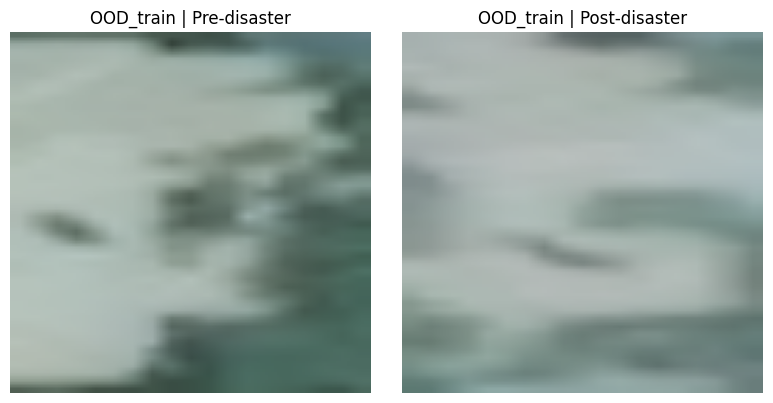


=== OOD_test ===
instance_id: guatemala-volcano_00000000_0
damage_label: no-damage
crop_path: /Users/paolo/Desktop/OOD_processed/crops_np/OOD_test/guatemala-volcano_00000000_0.npy
shape: (128, 128, 6)
dtype: uint8
min/max: 16 246


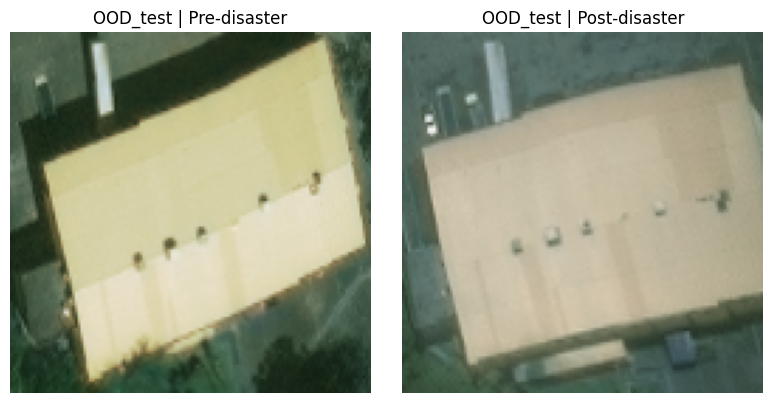


=== OOD_hold ===
instance_id: hurricane-michael_00000000_0
damage_label: no-damage
crop_path: /Users/paolo/Desktop/OOD_processed/crops_np/OOD_hold/hurricane-michael_00000000_0.npy
shape: (128, 128, 6)
dtype: uint8
min/max: 40 247


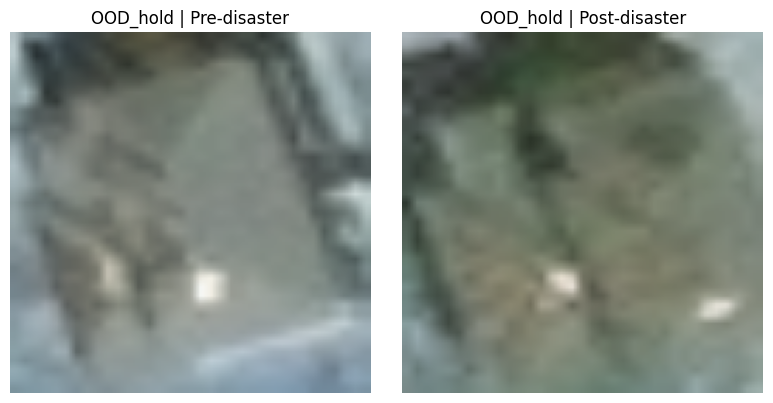

In [29]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
base_dir = Path.home() / "Desktop"
input_csv = base_dir / "OOD_processed" / "buildings_all_OOD_with_crops.csv"

# Load dataset
df = pd.read_csv(input_csv)

# Deterministic selection
df = df.sort_values(["split", "disaster", "image_id", "building_index"]).reset_index(drop=True)

# Pick one sample per OOD split
for split_name in ["OOD_train", "OOD_test", "OOD_hold"]:
    subset = df[df["split"] == split_name].reset_index(drop=True)

    if subset.empty:
        print(f"\nNo rows found for split: {split_name}")
        continue

    row = subset.iloc[0]
    x = np.load(row["crop_path"])

    print(f"\n=== {split_name} ===")
    print("instance_id:", row["instance_id"])
    print("damage_label:", row["damage_label"])
    print("crop_path:", row["crop_path"])
    print("shape:", x.shape)
    print("dtype:", x.dtype)
    print("min/max:", x.min(), x.max())

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(x[:, :, :3].astype("uint8"))
    axes[0].set_title(f"{split_name} | Pre-disaster")
    axes[0].axis("off")

    axes[1].imshow(x[:, :, 3:].astype("uint8"))
    axes[1].set_title(f"{split_name} | Post-disaster")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()